In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\sonu kumar jha\OneDrive\Desktop\media reach analysis\data\social_media_performance.csv")

print(df.head())

   post_id  platform content_type       topic language region  \
0        1  LinkedIn      article  Technology       UR     BR   
1        2  LinkedIn         poll      Health       FR     JP   
2        3  LinkedIn      article      Travel       HI     FR   
3        4  LinkedIn        image      Sports       DE     DE   
4        5  LinkedIn         poll    Business       DE     US   

         post_datetime                                           hashtags  \
0  2025-04-25 09:47:00  #AI #Innovation #TechTrends #Programming #Codi...   
1  2025-10-29 09:44:00  #Fitness #Nutrition #Wellness #Health #MentalH...   
2  2025-02-10 14:12:00  #Travel #Journey #Adventure #Tourism #ExploreM...   
3  2025-04-18 22:41:00                         #Cricket #Workout #Fitness   
4  2025-04-28 10:17:00             #Entrepreneur #Leadership #StartupLife   

   sentiment_score  views  likes  comments  shares  engagement_rate  is_viral  
0             0.76  37781   1202       462     185           0.049

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          10000 non-null  int64  
 1   platform         10000 non-null  object 
 2   content_type     10000 non-null  object 
 3   topic            10000 non-null  object 
 4   language         10000 non-null  object 
 5   region           10000 non-null  object 
 6   post_datetime    10000 non-null  object 
 7   hashtags         10000 non-null  object 
 8   sentiment_score  10000 non-null  float64
 9   views            10000 non-null  int64  
 10  likes            10000 non-null  int64  
 11  comments         10000 non-null  int64  
 12  shares           10000 non-null  int64  
 13  engagement_rate  10000 non-null  float64
 14  is_viral         10000 non-null  int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 1.1+ MB
None
           post_id  sentiment_score        

In [4]:
print(df.isnull().sum())


post_id            0
platform           0
content_type       0
topic              0
language           0
region             0
post_datetime      0
hashtags           0
sentiment_score    0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
is_viral           0
dtype: int64


In [6]:
df.dropna(inplace=True)

In [7]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

0


In [10]:
# clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

print(df.columns)

Index(['post_id', 'platform', 'content_type', 'topic', 'language', 'region',
       'post_datetime', 'hashtags', 'sentiment_score', 'views', 'likes',
       'comments', 'shares', 'engagement_rate', 'is_viral'],
      dtype='object')


In [20]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'])

df['day'] = df['post_datetime'].dt.day_name()

In [14]:
# total reach (views)
print("Total Views:", df['views'].sum())

# total likes
print("Total Likes:", df['likes'].sum())

# avg engagement rate
print("Avg Engagement Rate:", df['engagement_rate'].mean())

Total Views: 2121421581
Total Likes: 152368747
Avg Engagement Rate: 0.11266720000000001


In [15]:
platform_analysis = df.groupby('platform')[['views','likes','comments','shares']].sum()
print(platform_analysis)

                views     likes  comments    shares
platform                                           
Instagram   641974187  62800527  24153547   9660680
LinkedIn     64533409   3313735   1274024    508871
Medium      124834876  10729289   4126155   1649697
YouTube    1290079109  75525196  29047670  11618349


In [16]:
content_analysis = df.groupby('content_type')['engagement_rate'].mean().sort_values(ascending=False)
print(content_analysis)

content_type
feed        0.152081
reel        0.145252
story       0.138121
carousel    0.116647
image       0.116517
article     0.114808
video       0.087711
poll        0.078742
Name: engagement_rate, dtype: float64


In [17]:
top_posts = df.sort_values(by='views', ascending=False).head(10)
print(top_posts[['post_id','platform','views','likes']])

      post_id platform   views   likes
9001     9002  YouTube  999022   42006
9337     9338  YouTube  998811   63877
9520     9521  YouTube  998585   45475
9714     9715  YouTube  998401   92387
9990     9991  YouTube  997879   93494
8982     8983  YouTube  997050   90911
8759     8760  YouTube  996904   31255
9740     9741  YouTube  996835  116255
9190     9191  YouTube  996801   11549
9355     9356  YouTube  996147   94966


In [21]:
day_analysis = df.groupby('day')['engagement_rate'].mean().sort_values(ascending=False)
print(day_analysis)

day
Friday       0.114609
Sunday       0.113679
Tuesday      0.113249
Thursday     0.113010
Saturday     0.112975
Wednesday    0.110621
Monday       0.110581
Name: engagement_rate, dtype: float64


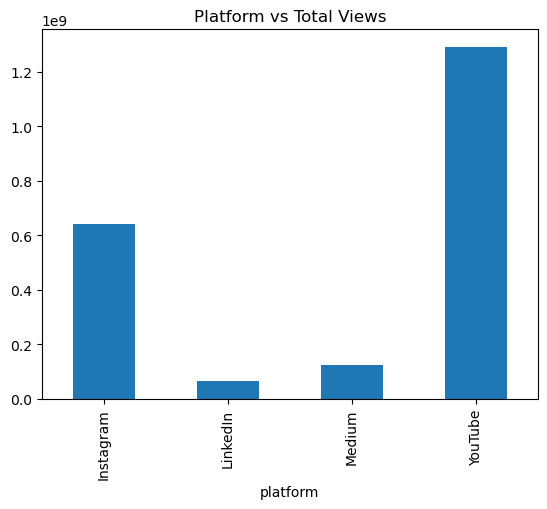

In [22]:
import matplotlib.pyplot as plt

df.groupby('platform')['views'].sum().plot(kind='bar')
plt.title("Platform vs Total Views")
plt.show()

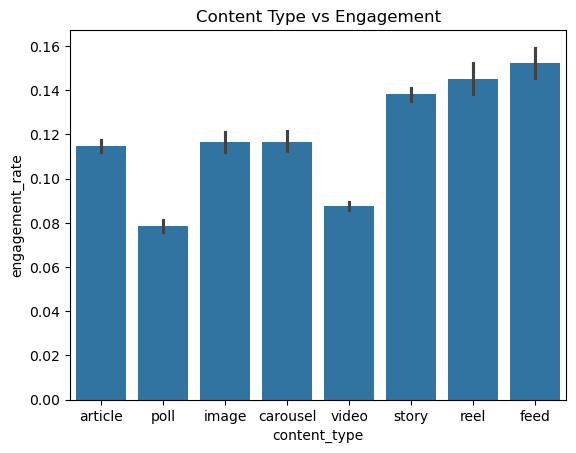

In [23]:
import seaborn as sns

sns.barplot(x=df['content_type'], y=df['engagement_rate'])
plt.title("Content Type vs Engagement")
plt.show()

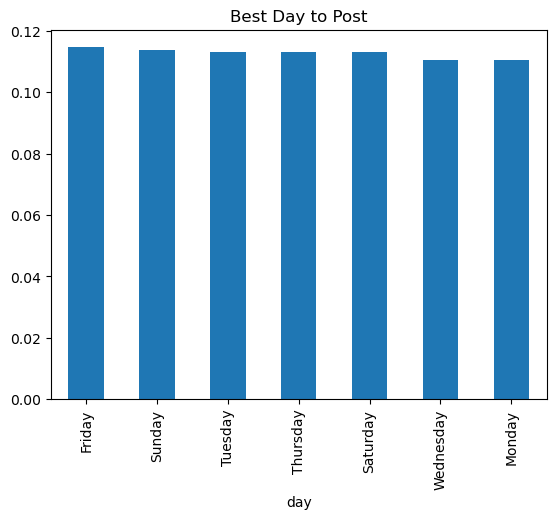

In [25]:
day_analysis.plot(kind='bar')
plt.title("Best Day to Post")
plt.show()

In [26]:
df.to_csv("clean_data.csv", index=False)